<a href="https://colab.research.google.com/github/Perlangas28/Simulacion_1/blob/main/Prueba_de_Frecuencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prueba de Frecuencias.

**Alumna: Perla Blancas Hernández**  
**Materia:** Simulación 1
**Prueba aplicada:** Prueba de Frecuencias.  

Hipótesis:

*   H₀: Las frecuencias observadas siguen la distribución esperada.
*   H₁: Las frecuencias observadas NO siguen la distribución esperada.

$H0​:p1​=p2​=⋯=pk$​

Nivel de confianza: α = 0.05


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm


datos = [
0.78961,0.05230,0.10639,0.55877,0.14151,
0.76086,0.12079,0.27738,0.65726,0.79269,
0.80548,0.82654,0.28453,0.20852,0.42989,
0.58518,0.98611,0.34488,0.34358,0.11537,
0.89898,0.57880,0.67621,0.05010,0.00121,
0.28269,0.73059,0.70119,0.18284,0.49962,
0.38618,0.76910,0.68334,0.55170,0.10850,
0.79982,0.45679,0.21631,0.87616,0.55743,
0.58962,0.33216,0.03185,0.61168,0.09264,
0.69623,0.17028,0.05475,0.91512,0.76262,
0.29931,0.30861,0.83358,0.51781,0.03272,
0.57410,0.26593,0.85903,0.43308,0.35286,
0.24000,0.65559,0.38507,0.90829,0.94187,
0.93655,0.88809,0.81772,0.36982,0.19904,
0.54325,0.62400,0.09133,0.41678,0.33954,
0.58244,0.85853,0.86752,0.38729,0.15506,
0.23949,0.53559,0.33381,0.49383,0.75103,
0.19962,0.65002,0.74579,0.79113,0.63453,
0.19147,0.40644,0.08128,0.73435,0.22724,
0.22287,0.07281,0.64183,0.44267,0.72102
]

N = len(datos)

print("Cantidad de datos (N):", N)

Cantidad de datos (N): 100


Primero definimos los intervalos y calculamos las frecuencias esperadas $(fo)$ y $(fe)$

In [ ]:
k = 10
n = len(datos)

intervalos = np.linspace(0, 1, k+1)
fo, _ = np.histogram(datos, bins=intervalos)
fe = np.array([n/k]*k)

Calculamos la estadística Ji-cuadrada aplicando la fórmula:
∑$((fo - fe)^2 / fe)$

In [ ]:
chi_cuadrada = np.sum((fo - fe)**2 / fe)

Calculamos el valor crítico

In [ ]:
from scipy.stats import chi2

alpha = 0.05
gl = k - 1
valor_critico = chi2.ppf(1 - alpha, gl)

Se toma la decisión

In [23]:
tabla = pd.DataFrame({
    "Intervalo": [f"[{intervalos[i]:.1f}, {intervalos[i+1]:.1f})" for i in range(k)],
    "fo": fo,
    "fe": fe,
    "(fo-fe)^2/fe": (fo - fe)**2 / fe
})

print("TABLA DE RESULTADOS\n")
display(tabla)

print(f"Ji-cuadrada calculada: {chi_cuadrada:.4f}")
print(f"Grados de libertad: {gl}")
print(f"Valor crítico (α=0.05): {valor_critico:.4f}")

if chi_cuadrada > valor_critico:
    print("\nDecisión: Se RECHAZA H0")
else:
    print("\nDecisión: NO se rechaza H0")

TABLA DE RESULTADOS



,Intervalo,fo,fe,(fo-fe)^2/fe
0,"[0.0, 0.1)",10,10.0,0.0
1,"[0.1, 0.2)",11,10.0,0.1
2,"[0.2, 0.3)",11,10.0,0.1
3,"[0.3, 0.4)",11,10.0,0.1
4,"[0.4, 0.5)",8,10.0,0.4
5,"[0.5, 0.6)",11,10.0,0.1
6,"[0.6, 0.7)",10,10.0,0.0
7,"[0.7, 0.8)",13,10.0,0.9
8,"[0.8, 0.9)",10,10.0,0.0
9,"[0.9, 1.0)",5,10.0,2.5


Ji-cuadrada calculada: 4.2000
Grados de libertad: 9
Valor crítico (α=0.05): 16.9190

Decisión: NO se rechaza H0


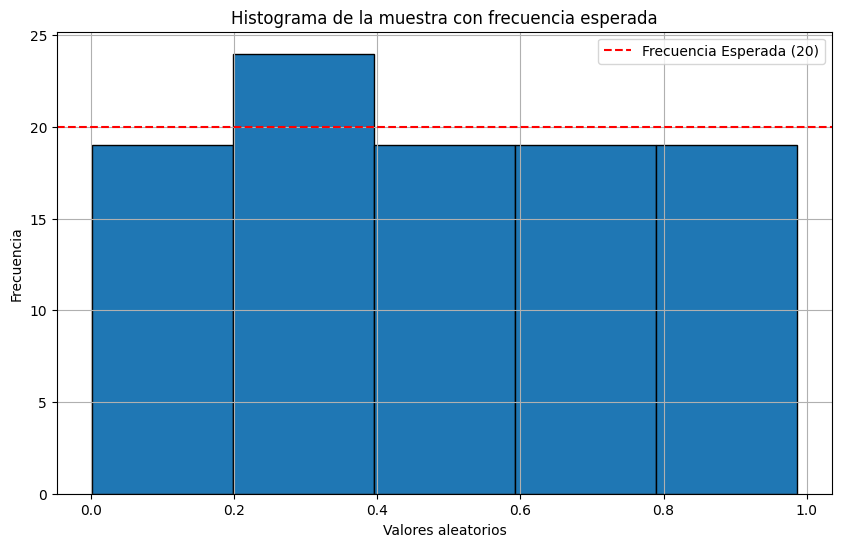

In [ ]:
import matplotlib.pyplot as plt

num_bins = 5
expected_frequency = N / num_bins

plt.figure(figsize=(10, 6))
plt.hist(datos, bins=num_bins, edgecolor='black')
plt.axhline(y=expected_frequency, color='red', linestyle='--', label=f'Frecuencia Esperada ({expected_frequency:.0f})')
plt.title("Histograma de la muestra con frecuencia esperada")
plt.xlabel("Valores aleatorios")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.legend()
plt.show()